# Incoherent Imaging

The incoherent imaging method is very similar to the coherent imaging technique. However, instead of the **amplitude spread function**, we convolve the **object irradiance** with the the imaging system's **point spread function**.<br>
The point spread function is simply the magnitude squared of the amplitude spread function.<br>

\begin{equation}
    I_i(u,v) = \int_{-\infty}^\infty \int_{-\infty}^\infty |h(u-\eta,v-\xi)|^2 I(\eta,\xi)d\eta d\xi = |h(u,v)|^2 \otimes I(u,v)
\end{equation}

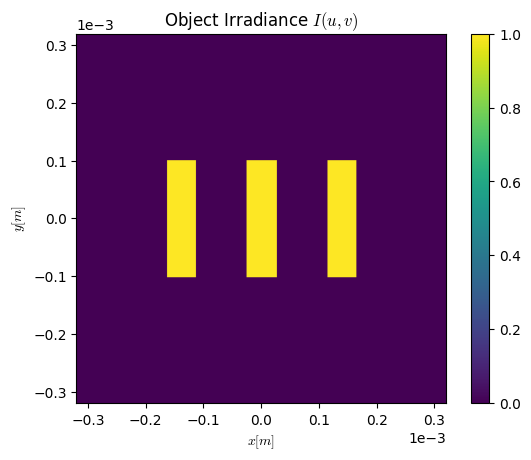

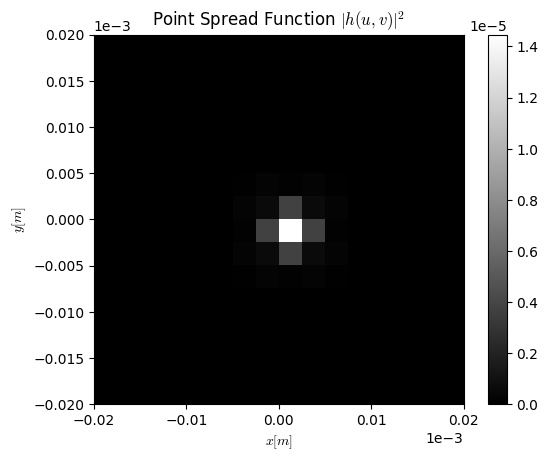

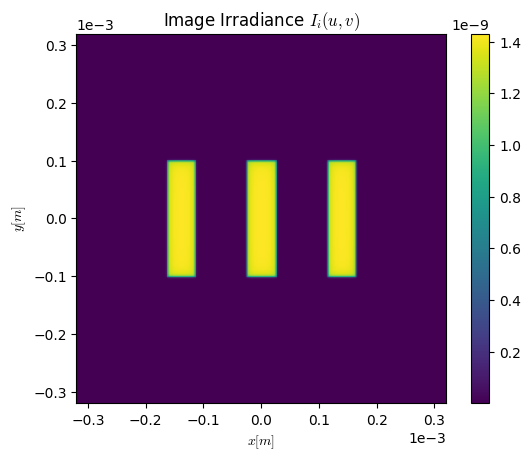

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from optprop.transforms import cart2pol
from optprop.zernike import zernike
from optprop.aperture_functions import circ, rect
from optprop.ft_functions import ft2, myconv2
N = 256
L = 0.1
D = 0.07
delta = L/N
wvl = 1e-6
z = 0.25

x = np.arange(-N/2,N/2,1) * delta
x,y = np.meshgrid(x,x)
r,theta = cart2pol(x,y)
W = 0.05 * zernike(4,2*r/D,theta)
P = circ(x,y,D) * np.exp(1j*np.pi*W)
h = ft2(P,delta)
U = (wvl*z)/(N*delta)
u = np.arange(-N/2,N/2,1) * U
u,v = np.meshgrid(u,u)
obj = (rect((u-1.4e-4)/5e-5) + rect(u/5e-5) + rect((u+1.4e-4)/5e-5)) * rect(v/2e-4)
img = myconv2(np.abs(obj)**2,np.abs(h)**2,1)
L2 = N * U

fig,ax = plt.subplots()
im = ax.imshow(np.abs(obj)**2,extent=[-L2/2,L2/2,-L2/2,L2/2])
fig.colorbar(im)
ax.ticklabel_format(axis='both',style='sci',scilimits=(-3,-3))
ax.set_xlabel(r"$x[m]$",math_fontfamily='cm')
ax.set_ylabel(r"$y[m]$",math_fontfamily='cm')
ax.set_title("Object Irradiance $I(u,v)$",math_fontfamily='cm')

fig,ax = plt.subplots()
im = ax.imshow(np.abs(h)**2,extent=[-L2/2,L2/2,-L2/2,L2/2],cmap='gray')
fig.colorbar(im)
ax.set_xlim(-0.02e-3,0.02e-3)
ax.set_ylim(-0.02e-3,0.02e-3)
ax.ticklabel_format(axis='both',style='sci',scilimits=(-3,-3))
ax.set_xlabel(r"$x[m]$",math_fontfamily='cm')
ax.set_ylabel(r"$y[m]$",math_fontfamily='cm')
ax.set_title("Point Spread Function $|h(u,v)|^2$",math_fontfamily='cm')

fig,ax = plt.subplots()
im = ax.imshow(np.abs(img)**2,extent=[-L2/2,L2/2,-L2/2,L2/2])
fig.colorbar(im)
ax.ticklabel_format(axis='both',style='sci',scilimits=(-3,-3))
ax.set_xlabel(r"$x[m]$",math_fontfamily='cm')
ax.set_ylabel(r"$y[m]$",math_fontfamily='cm')
ax.set_title("Image Irradiance $I_i(u,v)$",math_fontfamily='cm')

plt.show()